# Trend Analysis
This notebook first interpolates consistent data points for all glaciers over the whole time series. This ensures every glacier has the exact same amount of datapoints. With this complete time series, annual and monthly trend analysis can be conducted. Therefore the annual means and the monthly means are calculated and then fitted a linear regression to get the trend. 

*The Code in this notebook was written with the help of AI (Gemini, Version 3.1 Pro)*

In [1]:
# Setup and import
import pandas as pd
import numpy as np
import os
import glob
from scipy.stats import linregress
from IPython.display import display
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Define directories
composite_dir = '../data/LS_MODIS_combined/combination_post2017'
output_dir = '../data/Trend_Analysis'
os.makedirs(output_dir, exist_ok=True)

## 1. Interpolate consisten timeseries
To be able to calculate trends later, the same amount of data points for every year and every months is needed. Here the time series get interpolated to create a value for every day in the time series.

In [2]:
# Define the glaciers and load the files
study_glaciers = ['Ulluchiran', 'Lekziri', 'Caneri', 'Bezengi', 'Dyh-Cu', 'Agashtan', 'Karaugom']
composite_files = glob.glob(f"{composite_dir}/COMPOSITE_SLA_*_POST2017.csv")

# Dictionary to store the full, daily-interpolated dataframes
interpolated_dataframes = {}

for file_path in composite_files:
    name = os.path.basename(file_path).replace('COMPOSITE_SLA_', '').replace('_POST2017.csv', '')
    
    if name not in study_glaciers:
        continue
        
    df_comp = pd.read_csv(file_path)
    df_comp['date'] = pd.to_datetime(df_comp['date'])
    
    # Group by date to merge any duplicates
    df_unique = df_comp.groupby('date')[['Final_Composite_SLA']].mean()
    
    # Resample to daily and interpolate
    df_daily = df_unique.resample('D').interpolate(method='time')
    
    # Filter only for the target months: May-October
    df_season = df_daily[(df_daily.index.month >= 5) & (df_daily.index.month <= 10)]
    
    # Reset index so 'date' is a normal column again
    interpolated_dataframes[name] = df_season.reset_index()

## 2. Calculate Annual SLA Trends
For each glacier, annual summer SLA means are computed and a linear regression is fitted to detect long-term trends (m/yr). Results are saved and displayed sorted by trend magnitude.

In [16]:
trend_results = []
annual_summer_means = {} # for comparison plots later

# Loop through the interpolated dataframes 
for name, df in interpolated_dataframes.items():
    
    # Extract year 
    df['Year'] = df['date'].dt.year
    
    # Calculate annual mean 
    annual_mean = df.groupby('Year')['Final_Composite_SLA'].mean().dropna()
    annual_summer_means[name] = annual_mean    
    
    # Calculate trend
    if len(annual_mean) >= 5:
        res = linregress(annual_mean.index, annual_mean.values)
        
        trend_results.append({
            'Glacier': name,
            'Years of Data': len(annual_mean),
            'Interpolated SLA Trend (m/yr)': round(res.slope, 2),
            'Interpolated Total Shift (m)': round(res.slope * len(annual_mean), 1),
            'Interpolated P-value': round(res.pvalue, 4),
            'Interpolated R-squared': round(res.rvalue**2, 3),
            'Intercept': res.intercept
        })


# safe annual mean
pd.concat([
    v.rename('Mean_Summer_SLA')
     .reset_index()
     .assign(Glacier=k) 
    for k, v in annual_summer_means.items()
]).to_csv(f"{output_dir}/Annual_Summer_Means.csv", index=False)

# Display summary
df_trends = pd.DataFrame(trend_results)

if not df_trends.empty:
    df_trends = df_trends.sort_values('Interpolated SLA Trend (m/yr)', ascending=False).reset_index(drop=True)

    print("Annual Mean Trend Summary")
    display(df_trends)

    # Export
    #export_path = f"{output_dir}/Annual_Trends_INTERPOLATED.csv"
    #df_trends.to_csv(export_path, index=False)

Annual Mean Trend Summary


,Glacier,Years of Data,Interpolated SLA Trend (m/yr),Interpolated Total Shift (m),Interpolated P-value,Interpolated R-squared,Intercept
0,Caneri,26,7.31,190.1,0.0001,0.490,-11649.333455
1,Lekziri,26,6.15,159.9,0.0022,0.328,-9413.618015
2,Bezengi,26,4.22,109.6,0.0071,0.265,-5463.883633
3,Agashtan,26,3.61,93.8,0.0118,0.236,-4313.492065
4,Karaugom,26,3.57,92.9,0.0387,0.166,-3867.419491
5,Dyh-Cu,26,3.28,85.2,0.0831,0.120,-3557.893013
6,Ulluchiran,26,1.02,26.4,0.4110,0.028,1811.535103


## 3. Visualize the changing signal
This shows the annual means over the 26 years and fits the trend line.

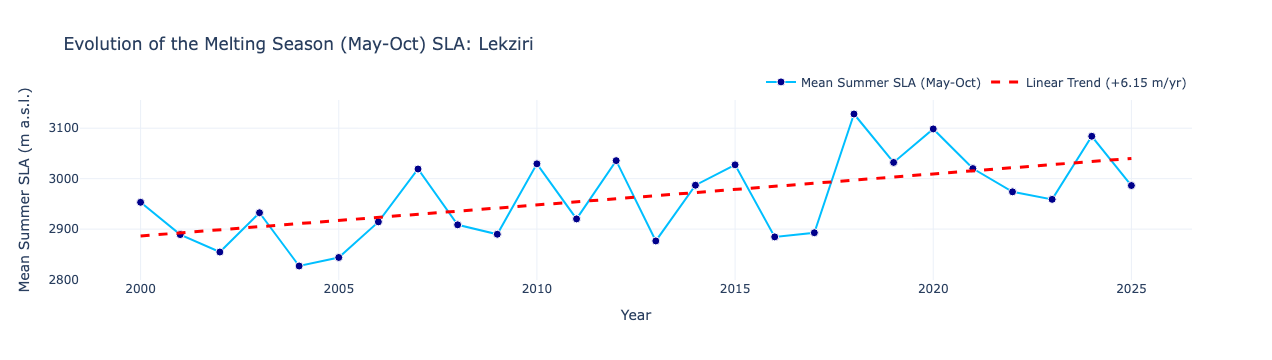

In [4]:
# Visualise the changing melt season signal 
GLACIER_TO_PLOT = 'Lekziri' 

if GLACIER_TO_PLOT in annual_summer_means and GLACIER_TO_PLOT in df_trends['Glacier'].values:
    
    # Get the raw data and stats 
    g_data = annual_summer_means[GLACIER_TO_PLOT]
    stats = df_trends[df_trends['Glacier'] == GLACIER_TO_PLOT].iloc[0]
    
    # Calculate the Y values for the trendline (y = mx + b)
    trendline_y = (stats['Interpolated SLA Trend (m/yr)'] * g_data.index) + stats['Intercept']
    
    fig_trend = go.Figure()
    
    # Trace 1: The Annual Melting Season Means
    fig_trend.add_trace(go.Scatter(
        x=g_data.index, 
        y=g_data.values,
        mode='lines+markers',
        name='Mean Summer SLA (May-Oct)',
        line=dict(color='deepskyblue', width=2),
        marker=dict(size=8, color='darkblue', line=dict(color='white', width=1))
    ))
    
    # Trace 2: The Trendline
    fig_trend.add_trace(go.Scatter(
        x=g_data.index, 
        y=trendline_y,
        mode='lines',
        name=f"Linear Trend ({stats['Interpolated SLA Trend (m/yr)']:+.2f} m/yr)",
        line=dict(color='red', width=3, dash='dash')
    ))
    
    fig_trend.update_layout(
        title=f"Evolution of the Melting Season (May-Oct) SLA: {GLACIER_TO_PLOT}",
        xaxis_title="Year",
        yaxis_title="Mean Summer SLA (m a.s.l.)",
        template="plotly_white",
        hovermode="x unified",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    
    fig_trend.show()
else:
    print(f"Error: Could not find data or trend statistics for {GLACIER_TO_PLOT}.")

## 4. Display Annual Mean SLA Anomalies for 3 close glaciers
To see how three geographically close glaciers (Bezengi, Caneri and Dyh-Cu) behave, plot their anomalies together. 

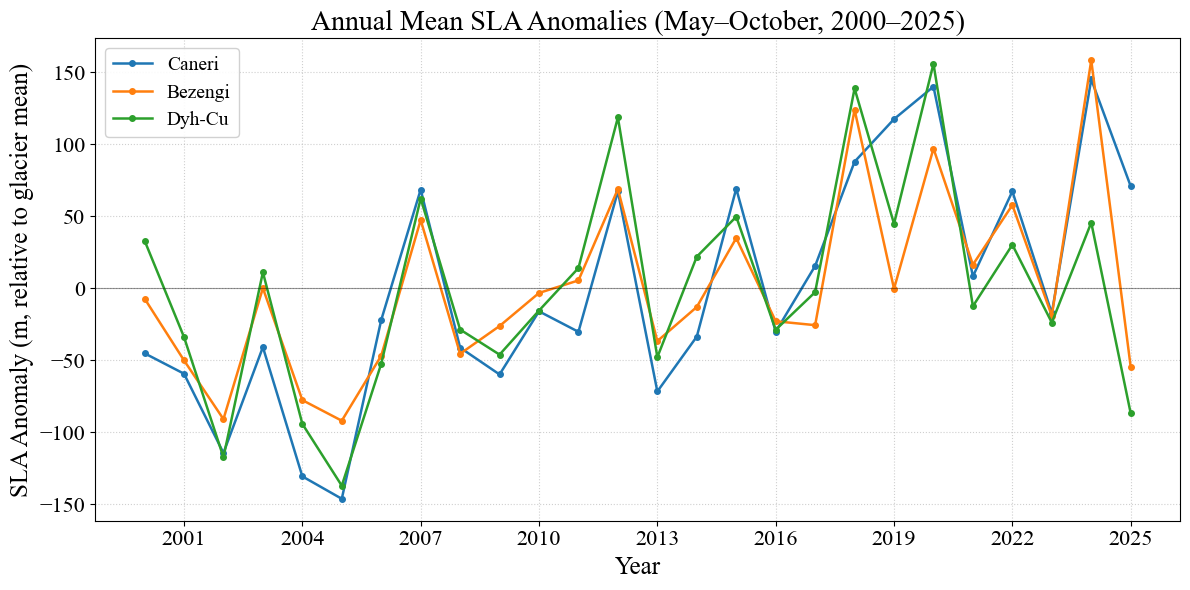

In [6]:
# Font type and size settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "serif"],
    "mathtext.fontset": "cm", 
    "xtick.labelsize": 16,    
    "ytick.labelsize": 16,    
    "axes.labelsize": 18,     
    "axes.titlesize": 20,     
    "legend.fontsize": 14,    
    "figure.titlesize": 20    
})

study_glaciers = ['Caneri', 'Bezengi', 'Dyh-Cu']

colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(12, 6))

for i, glacier in enumerate(study_glaciers):
    if glacier not in annual_summer_means:
        continue
    
    g_data = annual_summer_means[glacier]
    
    # Normalize by subtracting the glacier's own mean
    g_normalized = g_data - g_data.mean()
    
    ax.plot(
        g_normalized.index, g_normalized.values,
        color=colors[i], linewidth=1.8,
        marker='o', markersize=4,
        label=glacier
    )



# Add a horizontal zero line for reference
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)

ax.set_xlabel("Year")
ax.set_ylabel("SLA Anomaly (m, relative to glacier mean)")
ax.set_title("Annual Mean SLA Anomalies (May–October, 2000–2025)")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

output_path = "../results/Annual_Trend_Analysis/Regional_SLA_Anomalies.png"
fig.savefig(output_path, dpi=300, bbox_inches='tight')

## 6. Calculate the monthly trends
For each glacier, a separate linear regression is fitted for each month (May–October) over the study period (2000-2026). 
For example, all the July mean SLA values across years are used to calculate a July-specific trend. This gives a trend for each glacier and every month. 
The results are exported to CSV.

In [7]:
monthly_trend_results = []

# Loop through the interpolated dataframes
for name, df in interpolated_dataframes.items():
    
    df['Year'] = df['date'].dt.year
    df['Month'] = df['date'].dt.month
    
    for month in range(5, 11):  # May=5 to October=10
        # Filter to this month only
        df_month = df[df['Month'] == month]
        
        # Calculate annual mean for this month
        monthly_mean = df_month.groupby('Year')['Final_Composite_SLA'].mean().dropna()
        
        # Need at least 5 years of data to calculate a trend
        if len(monthly_mean) >= 5:
            res = linregress(monthly_mean.index, monthly_mean.values)
            time_span = monthly_mean.index.max() - monthly_mean.index.min() + 1
            
            # Count every single valid observation in this month
            total_obs = df_month['Final_Composite_SLA'].count()
            
            monthly_trend_results.append({
                'Glacier': name,
                'Month': month,
                'Month Name': pd.Timestamp(2000, month, 1).strftime('%B'),
                'Years of Data': len(monthly_mean),
                'Total Interpolated Days': total_obs,
                'SLA Trend (m/yr)': round(res.slope, 2),
                'Total Shift (m)': round(res.slope * time_span, 1),
                'P-value': round(res.pvalue, 4),
                'R-squared': round(res.rvalue**2, 3)
            })

df_monthly_trends = pd.DataFrame(monthly_trend_results)

if not df_monthly_trends.empty:
    df_monthly_trends = df_monthly_trends.sort_values(['Glacier', 'Month']).reset_index(drop=True)
    
    
    # Export
    export_path_monthly = f"{output_dir}/Monthly_Trends_INTERPOLATED.csv"
    df_monthly_trends.to_csv(export_path_monthly, index=False)

MONTHLY TREND SUMMARY


,Glacier,Month,Month Name,Years of Data,Total Interpolated Days,SLA Trend (m/yr),Total Shift (m),P-value,R-squared
0,Agashtan,5,May,26,806,-4.97,-129.2,0.0204,0.204
1,Agashtan,6,June,26,780,2.60,67.7,0.1807,0.073
2,Agashtan,7,July,26,806,3.22,83.8,0.0519,0.148
3,Agashtan,8,August,26,806,6.20,161.2,0.0027,0.318
4,Agashtan,9,September,26,780,10.40,270.4,0.0045,0.291
5,Agashtan,10,October,26,806,4.37,113.5,0.1026,0.107
6,Bezengi,5,May,26,806,3.74,97.2,0.2505,0.055
7,Bezengi,6,June,26,780,3.58,93.1,0.0538,0.146
8,Bezengi,7,July,26,806,2.62,68.1,0.1149,0.100
9,Bezengi,8,August,26,806,6.89,179.3,0.0007,0.390


## 7. Color the monthly trend
The monthly trend results are visualised as a heatmap with glaciers as rows and melt season months (May–October) as columns. Each cell shows the SLA trend in m/yr, colour-coded from blue (negative) to red (positive). Trends that are statistically significant (p < 0.05) are marked with an asterisk (*).

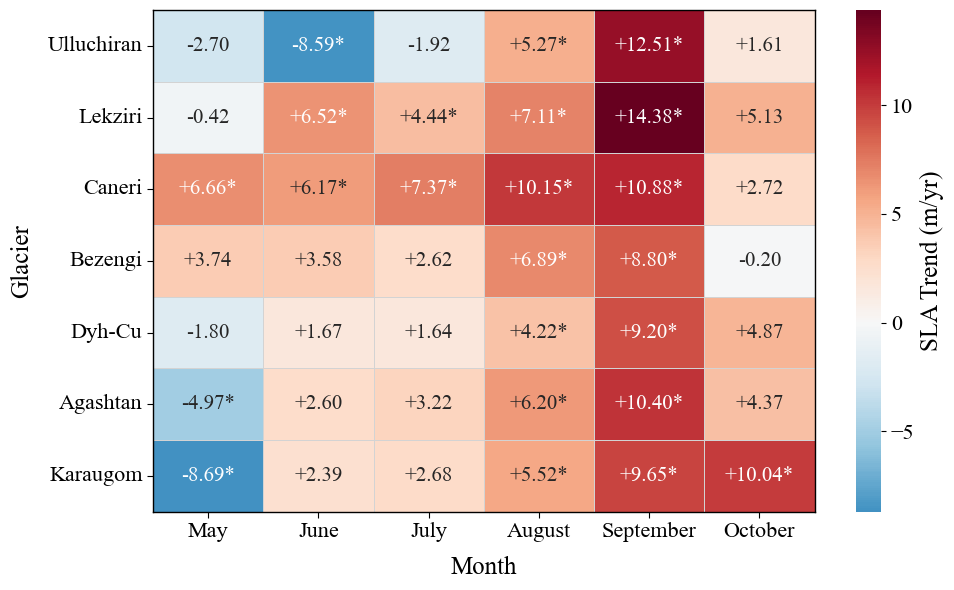

In [9]:
import seaborn as sns

# Font type and size settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "serif"],
    "mathtext.fontset": "cm", 
    "xtick.labelsize": 16,    
    "ytick.labelsize": 16,    
    "axes.labelsize": 18,     
    "axes.titlesize": 20,     
    "legend.fontsize": 13,    
    "figure.titlesize": 20    
})

# 1. Create the 'Significant' column based on the P-value 
df_monthly_trends['Significant (p<0.05)?'] = df_monthly_trends['P-value'].apply(lambda p: 'Yes' if p < 0.05 else 'No')

# Filter to your 7 study glaciers only
study_glaciers = ['Ulluchiran', 'Lekziri', 'Caneri', 'Bezengi', 'Dyh-Cu', 'Agashtan', 'Karaugom']
df_study = df_monthly_trends[df_monthly_trends['Glacier'].isin(study_glaciers)]

# Pivot to matrix format for the heatmap values
heatmap_data = df_study.pivot(
    index='Glacier',
    columns='Month Name',
    values='SLA Trend (m/yr)'
)

# Reorder columns and rows
month_order = ['May', 'June', 'July', 'August', 'September', 'October']
heatmap_data = heatmap_data.reindex(index=study_glaciers, columns=month_order)

# Significance matrix
sig_data = df_study.pivot(
    index='Glacier',
    columns='Month Name',
    values='Significant (p<0.05)?'
).reindex(index=study_glaciers, columns=month_order)

# Build a matching matrix of strings for the text annotations 
annot_data = pd.DataFrame(index=heatmap_data.index, columns=heatmap_data.columns)

for glacier in study_glaciers:
    for month in month_order:
        val = heatmap_data.loc[glacier, month]
        sig = sig_data.loc[glacier, month]
        
        if pd.isna(val):
            annot_data.loc[glacier, month] = 'N/A'
        else:
            star = '*' if sig == 'Yes' else ''
            annot_data.loc[glacier, month] = f"{val:+.2f}{star}"

# Build Static Figure
fig, ax = plt.subplots(figsize=(10, 6))

# Create the Seaborn Heatmap
sns.heatmap(
    heatmap_data, 
    annot=annot_data,     
    fmt="",               
    cmap='RdBu_r',        
    center=0,             
    linewidths=0.5,                
    linecolor='lightgrey',         
    cbar_kws={'label': 'SLA Trend (m/yr)'}, 
    annot_kws={'size': 15}, 
    ax=ax
)

# solid black bounding box
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1)

# layout and formatting
ax.tick_params(left=True, bottom=True, length=4, color='black')

ax.set_xlabel("Month", labelpad=10)
ax.set_ylabel("Glacier", labelpad=10)

plt.xticks()
plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()

# Export the image (uncomment to save)
output_path = f"../results/Monthly_trend_analysis/Monthly_Heatmap_MatchedStyle.png"
fig.savefig(output_path, dpi=300, bbox_inches='tight')